In [3]:
import torch
import torch.nn as nn
import numpy as np
import math
import time
import matplotlib.pyplot as plt

from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
baseline_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
baseline_model.eval()

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

In [5]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_dataset.set_format("torch")

eval_loader = DataLoader(tokenized_dataset["validation"], batch_size=8)

In [6]:
def evaluate_perplexity(model, dataloader):
    model.eval()
    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            labels = input_ids.clone()
            labels[attention_mask == 0] = -100

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            num_tokens = attention_mask.sum().item()

            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

    avg_loss = total_loss / total_tokens
    return math.exp(avg_loss)

In [7]:
baseline_ppl = evaluate_perplexity(baseline_model, eval_loader)
print("Baseline GPT-2 Perplexity:", baseline_ppl)

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Baseline GPT-2 Perplexity: 59.10726717842898


In [8]:
class KroneckerLinear(nn.Module):
    def __init__(self, original_linear):
        super().__init__()

        W = original_linear.weight.data  # [3072, 768]
        bias = original_linear.bias.data if original_linear.bias is not None else None

        A = torch.randn(64, 32, device=device)
        B = torch.randn(48, 24, device=device)

        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)
        self.bias = nn.Parameter(bias.clone()) if bias is not None else None

    def forward(self, x):
        W_kron = torch.kron(self.A, self.B)  # [3072, 768]
        out = torch.matmul(x, W_kron.t())

        if self.bias is not None:
            out = out + self.bias

        return out

In [9]:
def compress_single_layer(model, layer_idx):
    block = model.transformer.h[layer_idx]
    original_fc = block.mlp.c_fc
    block.mlp.c_fc = KroneckerLinear(original_fc)

In [10]:
isolated_ppl = []

for layer_idx in range(12):
    model_temp = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    model_temp.eval()

    compress_single_layer(model_temp, layer_idx)

    ppl = evaluate_perplexity(model_temp, eval_loader)
    isolated_ppl.append(ppl)

    print(f"Layer {layer_idx} isolated PPL: {ppl:.2f}")

Layer 0 isolated PPL: 9030.64
Layer 1 isolated PPL: 21866.72
Layer 2 isolated PPL: 88774.52
Layer 3 isolated PPL: 193393.23
Layer 4 isolated PPL: 282417.32
Layer 5 isolated PPL: 103431.40
Layer 6 isolated PPL: 77017.14
Layer 7 isolated PPL: 65540.72
Layer 8 isolated PPL: 99132.44
Layer 9 isolated PPL: 132683.81
Layer 10 isolated PPL: 34053.16
Layer 11 isolated PPL: 3482.98


In [11]:
cumulative_ppl = []

for k in range(13):  # 0 to 12 layers
    model_temp = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    model_temp.eval()

    for layer_idx in range(k):
        compress_single_layer(model_temp, layer_idx)

    ppl = evaluate_perplexity(model_temp, eval_loader)
    cumulative_ppl.append(ppl)

    print(f"Cumulative {k} layers PPL: {ppl:.2f}")

Cumulative 0 layers PPL: 59.11
Cumulative 1 layers PPL: 13207.05
Cumulative 2 layers PPL: 152666.72
Cumulative 3 layers PPL: 54931.77
Cumulative 4 layers PPL: 57552.87
Cumulative 5 layers PPL: 32629.55
Cumulative 6 layers PPL: 12832.23
Cumulative 7 layers PPL: 19835.36
Cumulative 8 layers PPL: 14320.03
Cumulative 9 layers PPL: 14103.31
Cumulative 10 layers PPL: 18250.05
Cumulative 11 layers PPL: 18102.96
Cumulative 12 layers PPL: 10162.71


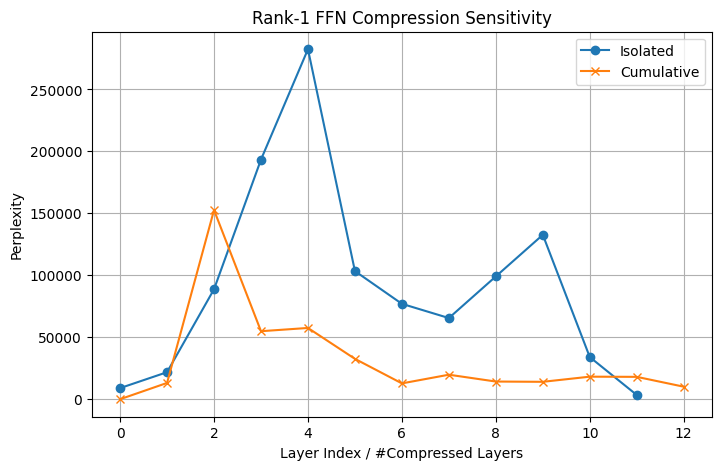

In [12]:
plt.figure(figsize=(8,5))

plt.plot(range(12), isolated_ppl, marker='o', label="Isolated")
plt.plot(range(13), cumulative_ppl, marker='x', label="Cumulative")

plt.xlabel("Layer Index / #Compressed Layers")
plt.ylabel("Perplexity")
plt.title("Rank-1 FFN Compression Sensitivity")
plt.legend()
plt.grid(True)
plt.show()

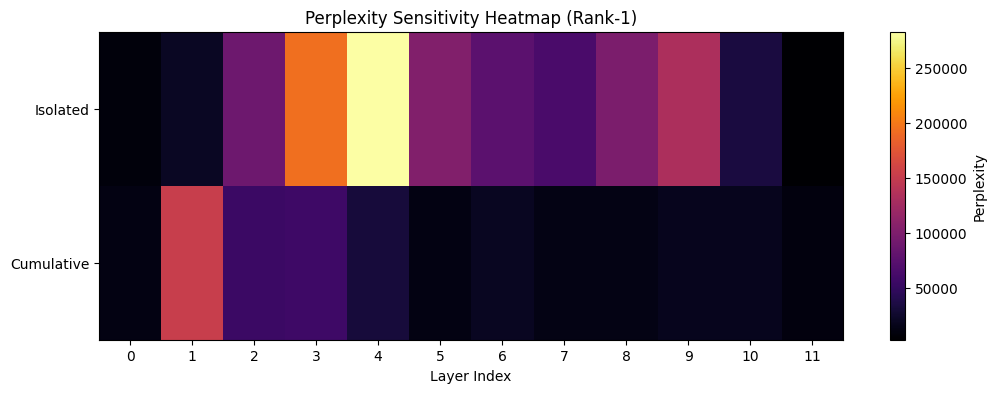

In [13]:
isolated_array = np.array(isolated_ppl).reshape(1, 12)
cumulative_array = np.array(cumulative_ppl[1:]).reshape(1, 12)

combined = np.vstack([isolated_array, cumulative_array])

plt.figure(figsize=(12,4))
plt.imshow(combined, aspect="auto", cmap="inferno")
plt.colorbar(label="Perplexity")

plt.yticks([0,1], ["Isolated", "Cumulative"])
plt.xticks(range(12), range(12))

plt.xlabel("Layer Index")
plt.title("Perplexity Sensitivity Heatmap (Rank-1)")
plt.show()